# Fase 1 - *Ex Ante*

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1 - Coleta e tratamento dos dados

In [81]:
marks = pd.read_csv("./data/marcacoes.csv")
proxies = pd.read_csv("./data/proxies.csv")

marks['data'] = pd.to_datetime(marks['data'])
proxies['data'] = pd.to_datetime(proxies['data'])

marks = marks.set_index("data").sort_index()
proxies = proxies.set_index("data").sort_index()

proxies

,OLEO3,FUEL3
data,,
2021-06-30,5.80,4.50
2021-07-01,5.60,4.53
2021-07-02,5.65,4.68
2021-07-05,5.65,4.87
2021-07-06,5.86,4.72
...,...,...
2026-06-24,42.65,11.43
2026-06-25,42.15,11.52
2026-06-26,40.49,11.79


#### Tratando os dados de proxies - Plotando as séries originais

Vamos observar como se comportam as séries temporais das proxies

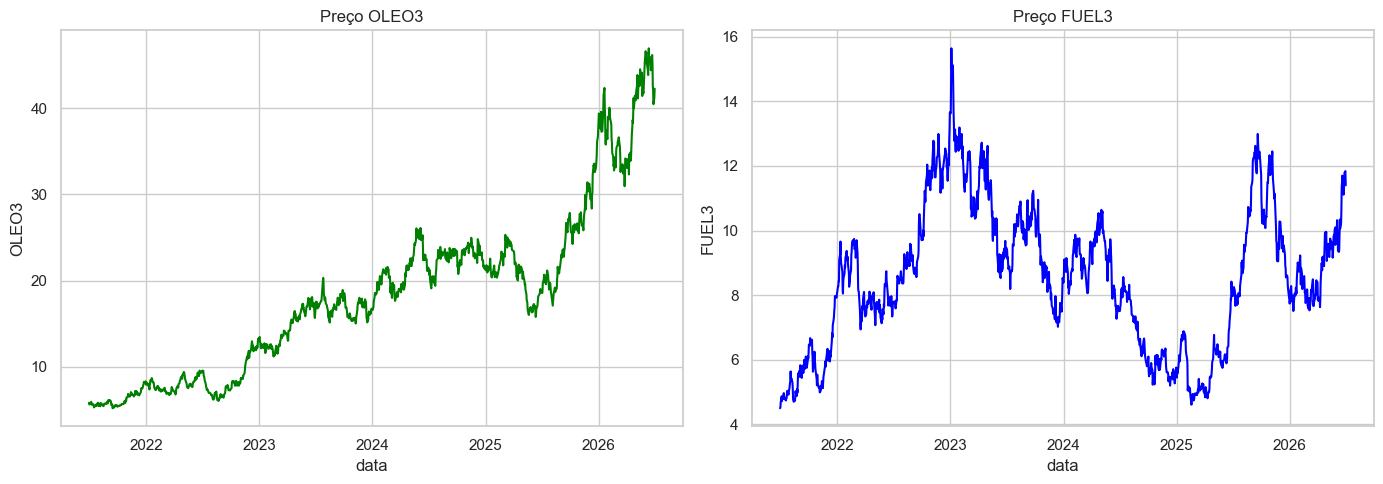

In [82]:
# OLEO3

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.lineplot(proxies['OLEO3'], ax=axes[0], color='green')
axes[0].set_title(f'Preço OLEO3')

sns.lineplot(proxies['FUEL3'], ax=axes[1], color='blue')
axes[1].set_title(f'Preço FUEL3')

plt.tight_layout()
plt.show()



### Analisando as séries

Podemos observar em ambos os casos que temos séries não estacionárias (i.e. média e variância não são constantes). Para operar melhor com essas séries, o ideal é criarmos uma versão normalizada dos dados, registrando as variações entre dois datapoints seguidos.

### Versão normalizada dos dados

Utilizando a função `pct_change()` do pandas, podemos fazer a diferenciação percentual em cada dia dos valores dos proxies.

Exemplificando, considere os valores de uma série do proxies como $p_1, p_2, ..., p_t, ...$. A diferenciação é feita da seguinte forma:

$$
v_t = \frac{p_t - p_{t-1}}{p_{t-1}}
$$

Em que $v_t$ representa a variação percentual de $p_t$ em relação a $p_{t-1}$.

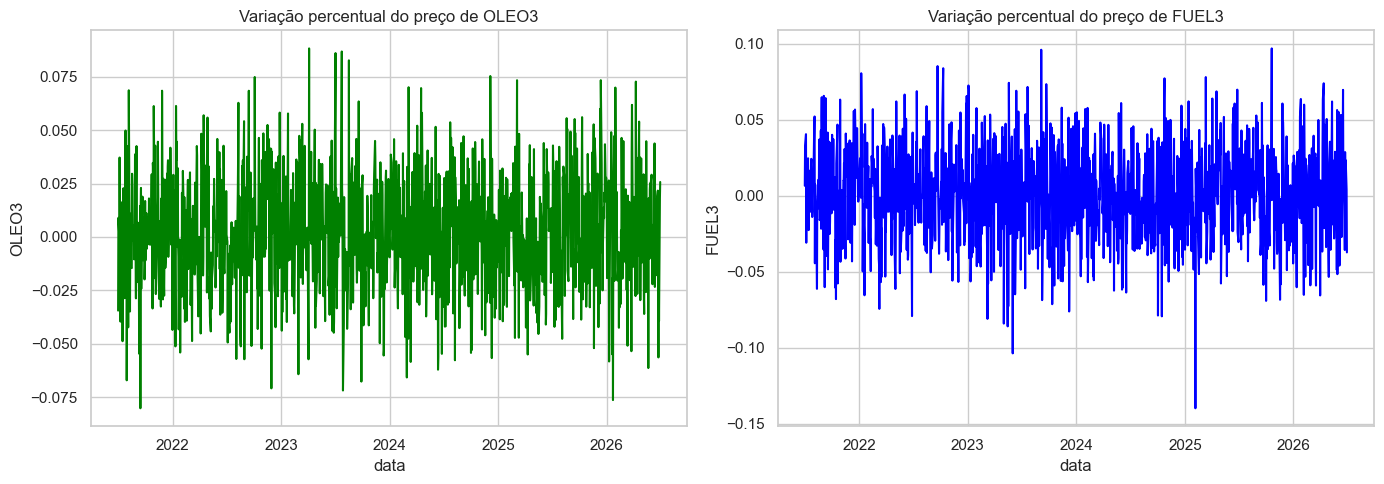

In [83]:
diff_proxies = proxies.pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.lineplot(diff_proxies['OLEO3'], ax=axes[0], color='green')
axes[0].set_title(f'Variação percentual do preço de OLEO3')

sns.lineplot(diff_proxies['FUEL3'], ax=axes[1], color='blue')
axes[1].set_title(f'Variação percentual do preço de FUEL3')

plt.tight_layout()
plt.show()


### Histograma das proxies vs. variações

Podemos comparar as distribuições das séries com as próprias diferenciadas nos gráficos abaixo:


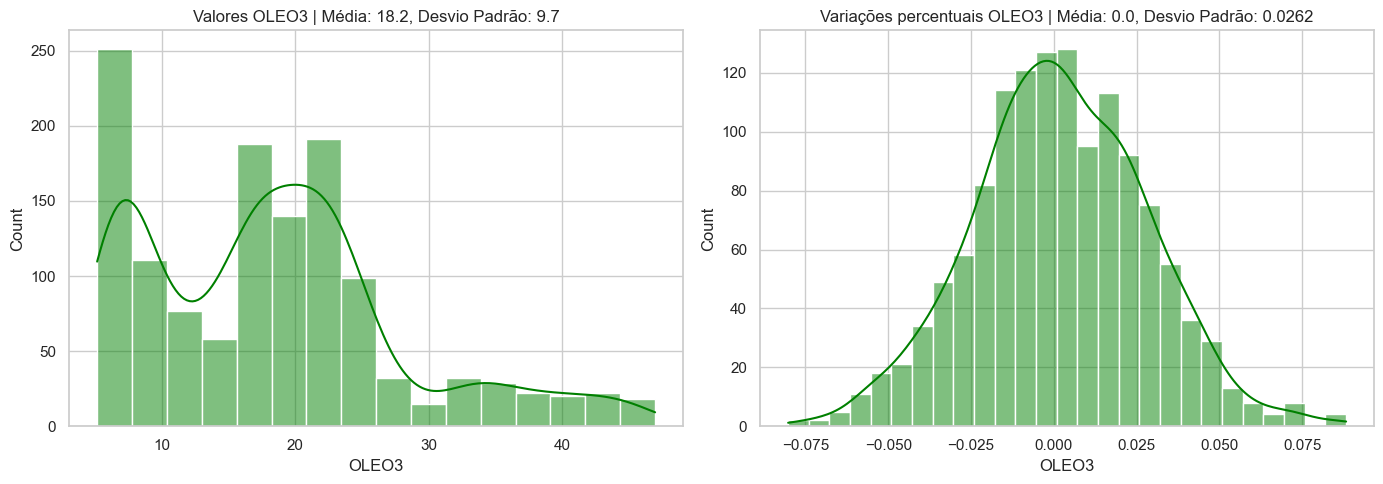

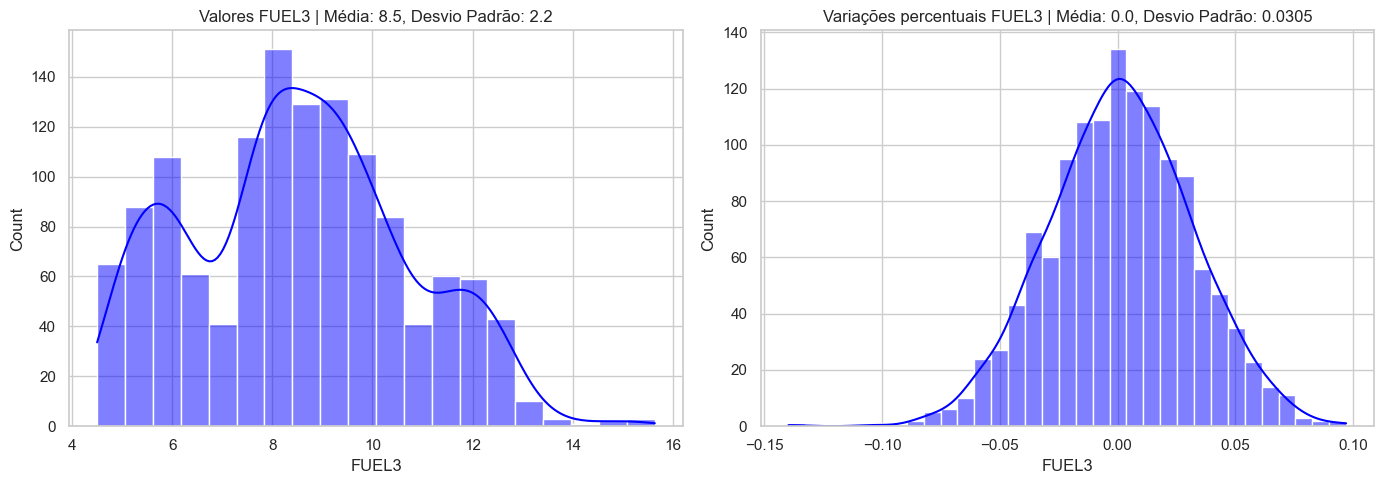

In [84]:

# OLEO3
oleo3_mean = proxies['OLEO3'].mean()
oleo3_std = proxies['OLEO3'].std()

oleo3_diff_mean = diff_proxies['OLEO3'].mean()
oleo3_diff_std = diff_proxies['OLEO3'].std()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(proxies['OLEO3'], kde=True, ax=axes[0], color='green')
axes[0].set_title(f'Valores OLEO3 | Média: {oleo3_mean:.1f}, Desvio Padrão: {oleo3_std:.1f}')

sns.histplot(diff_proxies['OLEO3'], kde=True, ax=axes[1], color='green')
axes[1].set_title(f'Variações percentuais OLEO3 | Média: {oleo3_diff_mean:.1f}, Desvio Padrão: {oleo3_diff_std:.4f}')

plt.tight_layout()
plt.show()

# FUEL3
fuel3_mean = proxies['FUEL3'].mean()
fuel3_std = proxies['FUEL3'].std()

fuel3_diff_mean = diff_proxies['FUEL3'].mean()
fuel3_diff_std = diff_proxies['FUEL3'].std()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(proxies['FUEL3'], kde=True, ax=axes[0], color='blue')
axes[0].set_title(f'Valores FUEL3 | Média: {fuel3_mean:.1f}, Desvio Padrão: {fuel3_std:.1f}')

sns.histplot(diff_proxies['FUEL3'], kde=True, ax=axes[1], color='blue')
axes[1].set_title(f'Variações percentuais FUEL3 | Média: {fuel3_diff_mean:.1f}, Desvio Padrão: {fuel3_diff_std:.4f}')

plt.tight_layout()
plt.show()




### Média das variações das proxies

No mesmo dataframe, vamos criar a coluna `MEAN` onde iremos armazenar a média das variações nas séries `OLEO3` e `FUEL3`. Vamos utilizar aqui a média aritmética simples:

$$
v_t^{MEAN} = \frac{v_t^{OLEO3} + v_t^{FUEL3}}{2}
$$

Note que as variações para as séries `OLEO3` e `FUEL3` possuem uma distribuição bem próxima à curva normal. Por consequência estatística, `MEAN` terá uma distribuição semelhante

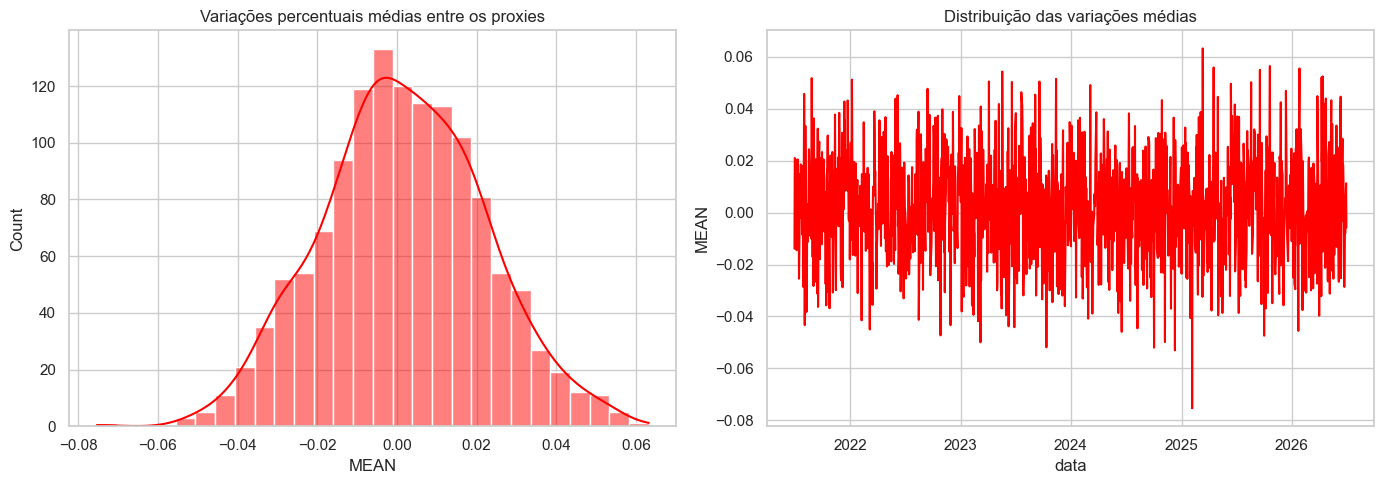

In [85]:
diff_proxies["MEAN"] = diff_proxies.mean(axis=1)


fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(diff_proxies['MEAN'], kde=True, ax=axes[0], color='red')
axes[0].set_title(f'Variações percentuais médias entre os proxies')

sns.lineplot(diff_proxies['MEAN'], ax=axes[1], color='red')
axes[1].set_title("Distribuição das variações médias")

plt.tight_layout()
plt.show()


### Visualização das Séries

Comparando o histórico das marcações com a média de variação das proxies

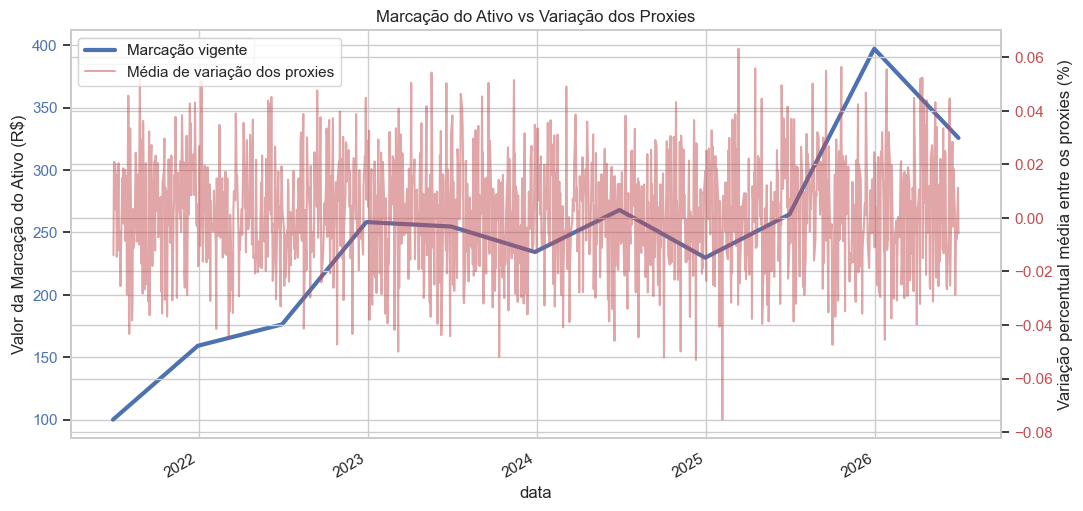

In [86]:

fig, ax1 = plt.subplots(figsize=(12,6))

sns.lineplot(marks, x="data", y="valor", label="Marcação vigente", ax=ax1, color='b', linewidth=3)
ax1.set_ylabel('Valor da Marcação do Ativo (R$)')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
sns.lineplot(diff_proxies, x="data", y="MEAN", label="Média de variação dos proxies", ax=ax2, color='r', alpha=0.5)
ax2.set_ylabel('Variação percentual média entre os proxies (%)')
ax2.tick_params(axis='y', labelcolor='r')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

fig.autofmt_xdate()

plt.title('Marcação do Ativo vs Variação dos Proxies')
plt.show()

### Alinhamento de datas

A dataset de marcações está indexado de forma semestral. Para alinhar com o dataset de proxies, vamos inserir os índices para todos os dias preenchendo para cada dia a marcação mais recente.

In [87]:
all_dates_marks = marks.reindex(diff_proxies.index, method="ffill")

### Selecionando dados de interesse

Afinal, queremos saber dos valores após a marcação `M10`, então vamos trabalhar com esses dados somente.

In [94]:
date_m10 = marks.index[-2]
value_m10 = marks.loc[date_m10, 'valor']

post_m10_diff_proxies = diff_proxies.loc[date_m10:]